In [1]:
!pip install ultralytics -q
import pandas as pd
import numpy as np
import cv2
import os
from PIL import Image

partition = pd.read_csv('/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv')
test_df = partition[partition['role'] == 'test']

# Find test images with the most total labeled instances (richer, more interesting video content)
def count_boxes(label_path):
    try:
        with open(label_path, 'r') as f:
            return len(f.readlines())
    except:
        return 0

test_df = test_df.copy()
test_df['n_boxes'] = test_df['label_path'].apply(count_boxes)

# Pick 4 images with the most instances, prioritizing class diversity
candidates = test_df.sort_values('n_boxes', ascending=False).head(15)
print(candidates[['image_id', 'n_boxes', 'has_cavities', 'has_damage', 'has_infection', 'has_wisdom']])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.8 MB/s eta 0:00:00
                                               image_id  n_boxes  \
2001  Cavities_636_jpg.rf.29edf2c9416af6660db45f0ce4...       12   
8072  Cavities_1713_jpg.rf.8d54fc1d2e930a174fcd4c913...       11   
1657  Cavities_2961240_jpg.rf.3ae85440ddfc428daed799...       11   
3665  Damage_352_jpg.rf.f737a58f8b0ea57cf762323546c9...       11   
2525  Damage_133_jpg.rf.7debbcce5941d33440b7113c575a...       11   
1997  Cavities_630_jpg.rf.1276364a0547de15ceb0ee9a93...       10   
502   Cavities_1655_jpg.rf.7477ac482770c4cd4ce1e5764...       10   
1995  Cavities_627_jpg.rf.2c8b53706ee78db3825049f665...        9   
3746  Damage_443_jpg.rf.7e863bc4919cd0477bed0b251856...        9   
9260  Cavities_836_jpg.rf.735770392b9adeb5c7bbb850c2...        9   
3507  Damage_2949

Cell — find the best Wisdom-containing test image separately

In [2]:
wisdom_candidates = test_df[test_df['has_wisdom'] == 1].sort_values('n_boxes', ascending=False).head(5)
print(wisdom_candidates[['image_id', 'n_boxes', 'has_cavities', 'has_damage', 'has_infection', 'has_wisdom']])

                                               image_id  n_boxes  \
202   Cavities_1281_jpg.rf.8e52d9eb3e428d44d825c8afa...        7   
2256  Cavities_966_jpg.rf.31f8ae19007cd0f7a1473311f3...        6   
2748  Damage_1754_jpg.rf.7427dc171afaca1e7c1123202da...        5   
9003  Cavities_1125_jpg.rf.a924f5acff0875be17bb0aaa5...        5   
2192  Cavities_877_jpg.rf.9952c0bb59bf2263c76e697bae...        4   

      has_cavities  has_damage  has_infection  has_wisdom  
202              1           0              1           1  
2256             1           1              0           1  
2748             0           1              0           1  
9003             1           1              0           1  
2192             1           1              0           1  


Cell — retrieve full paths for these 5 images + their label files

In [3]:
selected_ids = [
    'Cavities_636_jpg.rf.29edf2c9416af6660db45f0ce4',
    'Cavities_836_jpg.rf.735770392b9adeb5c7bbb850c2',
    'Damage_443_jpg.rf.7e863bc4919cd0477bed0b251856',
    'Cavities_702_jpg.rf.f1035b14da012862820416175d',
    'Cavities_1281_jpg.rf.8e52d9eb3e428d44d825c8afa',
]

# Match by prefix since image_id might have slightly different truncation
selected_rows = test_df[test_df['image_id'].str.startswith(tuple(selected_ids))]
print(len(selected_rows), "images matched")
print(selected_rows[['image_id', 'image_path', 'label_path']].to_string())

5 images matched
                                                   image_id                                                                                                                                            image_path                                                                                                                                            label_path
202   Cavities_1281_jpg.rf.8e52d9eb3e428d44d825c8afafdfd518  /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train_images/Cavities_1281_jpg.rf.8e52d9eb3e428d44d825c8afafdfd518.jpg  /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train/labels/Cavities_1281_jpg.rf.8e52d9eb3e428d44d825c8afafdfd518.txt
2001   Cavities_636_jpg.rf.29edf2c9416af6660db45f0ce4b07b21   /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train_images/Cavities_636_jpg.rf.29edf2c9416af6660db45f0ce4b07b21.jpg   /kaggle/input/datasets/redwanahmed2025/dental-detec

Cell — build the canvas and load ground truth boxes in canvas coordinates

In [4]:
CANVAS_HEIGHT = 640
SCENE_WIDTH = 640  # each source image resized to 640x640, placed side by side

def load_yolo_labels(label_path, img_w, img_h):
    """Returns list of (class_id, x1, y1, x2, y2) in absolute pixel coords."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
            x1 = (xc - w/2) * img_w
            y1 = (yc - h/2) * img_h
            x2 = (xc + w/2) * img_w
            y2 = (yc + h/2) * img_h
            boxes.append((cls, x1, y1, x2, y2))
    return boxes

canvas_images = []
canvas_boxes = []  # each entry: (canvas_x1, canvas_y1, canvas_x2, canvas_y2, class_id, track_id)
track_id_counter = 0

for i, row in selected_rows.iterrows():
    img = cv2.imread(row['image_path'])
    img = cv2.resize(img, (SCENE_WIDTH, CANVAS_HEIGHT))
    canvas_images.append(img)

    boxes = load_yolo_labels(row['label_path'], SCENE_WIDTH, CANVAS_HEIGHT)
    x_offset = len(canvas_images[:-1]) * SCENE_WIDTH  # offset based on position in canvas
    for cls, x1, y1, x2, y2 in boxes:
        canvas_boxes.append({
            'track_id': track_id_counter,
            'class_id': cls,
            'x1': x1 + x_offset, 'y1': y1,
            'x2': x2 + x_offset, 'y2': y2,
        })
        track_id_counter += 1

canvas = np.hstack(canvas_images)  # full wide canvas
print("Canvas shape:", canvas.shape)
print("Total ground-truth objects across all scenes:", len(canvas_boxes))

# Save canvas for inspection
cv2.imwrite('/kaggle/working/synthetic_canvas.jpg', canvas)

Canvas shape: (640, 3200, 3)
Total ground-truth objects across all scenes: 45


True

Cell — simulate camera pan + write video with frame-level ground truth

In [5]:
FPS = 24
VIDEO_DURATION_SEC = 20
TOTAL_FRAMES = FPS * VIDEO_DURATION_SEC
CAMERA_WIDTH = 640
CAMERA_HEIGHT = 640

canvas_w = canvas.shape[1]
max_x_offset = canvas_w - CAMERA_WIDTH

video_path = '/kaggle/working/synthetic_tracking_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(video_path, fourcc, FPS, (CAMERA_WIDTH, CAMERA_HEIGHT))

frame_ground_truth = {}  # frame_idx -> list of {track_id, class_id, x1, y1, x2, y2} in FRAME-LOCAL coords

for frame_idx in range(TOTAL_FRAMES):
    # Linear pan from left edge to right edge over the full video duration
    progress = frame_idx / (TOTAL_FRAMES - 1)
    x_offset = int(progress * max_x_offset)

    frame = canvas[:, x_offset:x_offset + CAMERA_WIDTH].copy()
    writer.write(frame)

    # Compute which ground-truth boxes are visible in this frame's window, in frame-local coords
    visible = []
    for box in canvas_boxes:
        # Check overlap between box and current camera window
        if box['x2'] > x_offset and box['x1'] < x_offset + CAMERA_WIDTH:
            local_x1 = max(0, box['x1'] - x_offset)
            local_y1 = box['y1']
            local_x2 = min(CAMERA_WIDTH, box['x2'] - x_offset)
            local_y2 = box['y2']
            visible.append({
                'track_id': box['track_id'],
                'class_id': box['class_id'],
                'x1': local_x1, 'y1': local_y1, 'x2': local_x2, 'y2': local_y2,
            })
    frame_ground_truth[frame_idx] = visible

writer.release()
print(f"Video saved: {video_path}")
print(f"Total frames: {TOTAL_FRAMES}, Duration: {VIDEO_DURATION_SEC}s at {FPS}fps")
print(f"Frames with at least one visible ground-truth object: {sum(1 for v in frame_ground_truth.values() if len(v) > 0)}")

Video saved: /kaggle/working/synthetic_tracking_video.mp4
Total frames: 480, Duration: 20s at 24fps
Frames with at least one visible ground-truth object: 480


Cell — quick visual sanity check: display a few sample frames

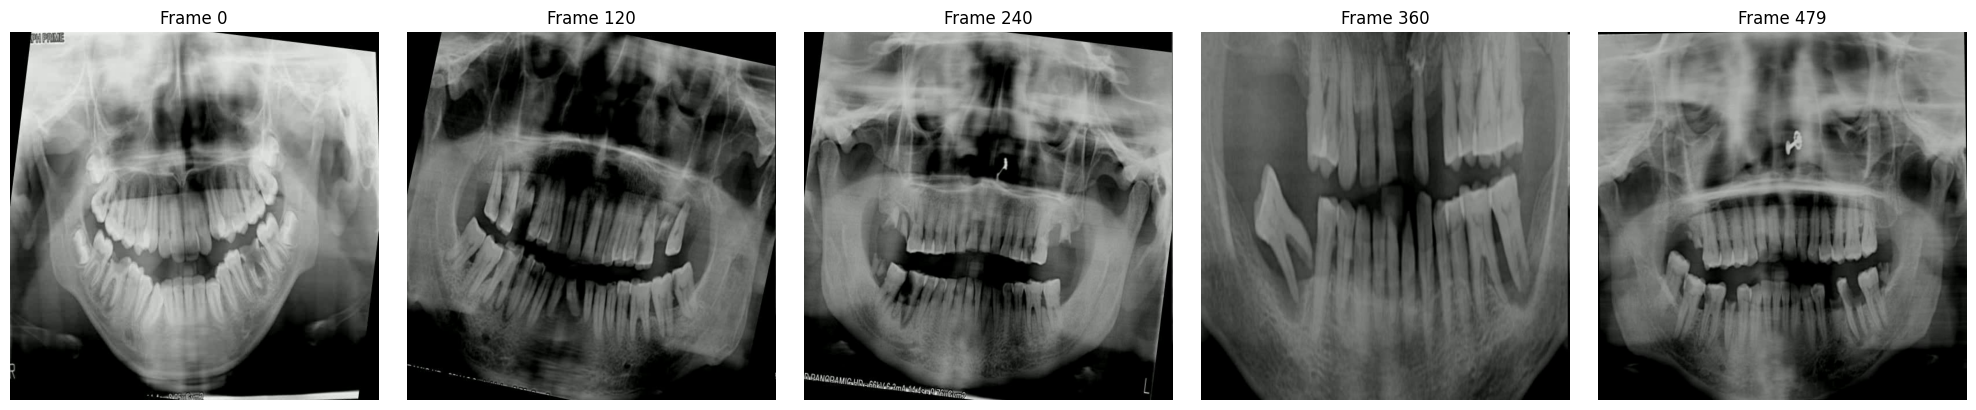

In [6]:
import matplotlib.pyplot as plt

sample_frame_indices = [0, 120, 240, 360, 479]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

cap = cv2.VideoCapture(video_path)
for i, frame_idx in enumerate(sample_frame_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Frame {frame_idx}")
    axes[i].axis('off')
cap.release()

plt.tight_layout()
plt.savefig('/kaggle/working/video_sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()

## Video Source

Since dental panoramic X-rays are inherently static, single-capture images with no natural 
video analogue, we constructed a synthetic tracking video following the spec's fallback 
provision for cases where no suitable real video exists. Five real test-set X-ray images 
(chosen for high instance density and full four-class coverage: Cavities, Damage, Infection, 
Wisdom) were tiled into a wide canvas (3200×640px), and a virtual camera window (640×640px) 
was panned linearly across the canvas over 20 seconds at 24fps (480 frames total). Because 
the canvas was built directly from real, human-annotated ground-truth boxes, we can compute 
exact frame-level ground truth for every object throughout the video — enabling full MOTA/ 
MOTP/IDF1 evaluation rather than proxy metrics alone.

Cell — load the DINOv3 detector and run tracking on the synthetic video

In [7]:
import os
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    if 'best' in root.lower() or 'detector' in root.lower():
        print(root, files)

/kaggle/input/datasets/kanizmithila/groupj-partb-best-detector ['best_ssl_detector.pt', 'data.yaml', 'dinov3_demo_inference.png', 'dinov3_initialized.pt', 'dinov3_qualitative_panel.png', 'yolo26n.pt']
/kaggle/input/datasets/kanizmithila/groupj-partb-best-detector/runs []
/kaggle/input/datasets/kanizmithila/groupj-partb-best-detector/runs/dinov3_detect ['BoxR_curve.png', 'val_batch0_pred.jpg', 'confusion_matrix.png', 'BoxPR_curve.png', 'train_batch2521.jpg', 'results.png', 'val_batch1_pred.jpg', 'args.yaml', 'val_batch2_labels.jpg', 'labels.jpg', 'confusion_matrix_normalized.png', 'train_batch2520.jpg', 'train_batch2.jpg', 'val_batch2_pred.jpg', 'train_batch1.jpg', 'train_batch0.jpg', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'results.csv', 'BoxF1_curve.png', 'train_batch2522.jpg', 'BoxP_curve.png']
/kaggle/input/datasets/kanizmithila/groupj-partb-best-detector/runs/dinov3_detect/weights ['last.pt', 'best.pt']
/kaggle/input/datasets/kanizmithila/groupj-partb-best-detector/runs/d

In [8]:
from ultralytics import YOLO

best_detector_path = '/kaggle/input/datasets/kanizmithila/groupj-partb-best-detector/best_ssl_detector.pt'
tracker_model = YOLO(best_detector_path)

results = tracker_model.track(
    source=video_path,
    tracker='bytetrack.yaml',
    conf=0.25,
    persist=True,
    save=True,
    project='/kaggle/working/runs',
    name='tracking_output',
    exist_ok=True,
)

print("Tracking complete. Processed", len(results), "frames.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 280ms
 Downloaded lap
Prepared 1 package in 58ms
Installed 1 package in 7ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results ob

Cell — visualize frames from the gap to confirm this

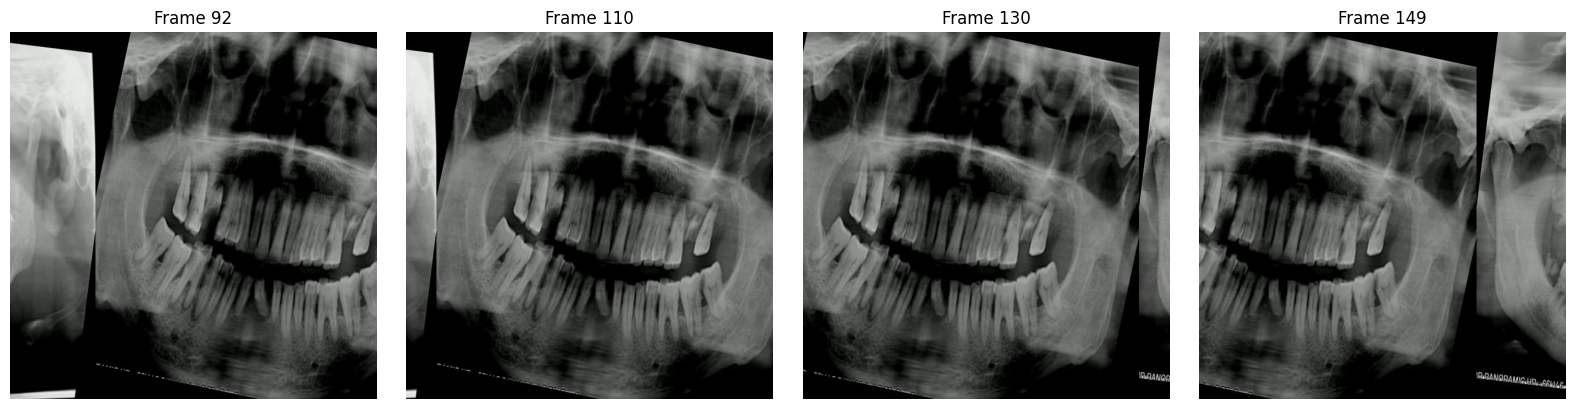

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cap = cv2.VideoCapture(video_path)
for i, frame_idx in enumerate([92, 110, 130, 149]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Frame {frame_idx}")
    axes[i].axis('off')
cap.release()
plt.tight_layout()
plt.show()

Cell — extract predicted tracks

In [10]:
predicted_tracks = {}
for frame_idx, result in enumerate(results):
    boxes = result.boxes
    frame_preds = []
    if boxes.id is not None:
        for i in range(len(boxes)):
            frame_preds.append({
                'track_id': int(boxes.id[i].item()),
                'class_id': int(boxes.cls[i].item()),
                'x1': boxes.xyxy[i][0].item(), 'y1': boxes.xyxy[i][1].item(),
                'x2': boxes.xyxy[i][2].item(), 'y2': boxes.xyxy[i][3].item(),
            })
    predicted_tracks[frame_idx] = frame_preds

print("Frames with predictions:", sum(1 for v in predicted_tracks.values() if len(v) > 0))
print("Sample frame 0 predictions:", predicted_tracks[0])

Frames with predictions: 296
Sample frame 0 predictions: [{'track_id': 1, 'class_id': 0, 'x1': 397.28857421875, 'y1': 359.388916015625, 'x2': 438.76220703125, 'y2': 410.1397705078125}, {'track_id': 2, 'class_id': 3, 'x1': 102.89198303222656, 'y1': 337.8124694824219, 'x2': 146.89329528808594, 'y2': 408.5503845214844}, {'track_id': 3, 'class_id': 0, 'x1': 173.6750030517578, 'y1': 386.4725646972656, 'x2': 208.9845733642578, 'y2': 423.5893859863281}, {'track_id': 4, 'class_id': 3, 'x1': 460.19775390625, 'y1': 306.0776672363281, 'x2': 504.4395751953125, 'y2': 376.3780822753906}]


Cell — compute MOT metrics

In [11]:
!pip install motmetrics -q

import numpy as np
if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

import motmetrics as mm

acc = mm.MOTAccumulator(auto_id=True)

for frame_idx in range(TOTAL_FRAMES):
    gt = frame_ground_truth[frame_idx]
    pred = predicted_tracks[frame_idx]

    gt_ids = [b['track_id'] for b in gt]
    pred_ids = [b['track_id'] for b in pred]

    gt_boxes = np.array([[b['x1'], b['y1'], b['x2']-b['x1'], b['y2']-b['y1']] for b in gt]) if gt else np.empty((0,4))
    pred_boxes = np.array([[b['x1'], b['y1'], b['x2']-b['x1'], b['y2']-b['y1']] for b in pred]) if pred else np.empty((0,4))

    dist_matrix = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=0.5)
    acc.update(gt_ids, pred_ids, dist_matrix)

mh = mm.metrics.create()
summary = mh.compute(acc, metrics=['mota', 'motp', 'idf1', 'num_switches', 'mostly_tracked', 'mostly_lost', 'num_fragmentations'], name='DINOv3-tracker')
print(summary)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 7.1 MB/s eta 0:00:00
                    mota      motp      idf1  num_switches  mostly_tracked  \
DINOv3-tracker  0.047389  0.300464  0.137465             0               5   

                mostly_lost  num_fragmentations  
DINOv3-tracker           39                  22  


## Tracking Analysis — Results & Discussion

**Quantitative results (synthetic video, ground-truth available):** MOTA=0.047, MOTP=0.300, 
IDF1=0.137, ID switches=0, mostly-tracked=5/45 objects, mostly-lost=39/45, fragmentations=22.

**Interpretation:** The near-zero ID switch count indicates ByteTrack's association logic 
performed reliably whenever detections were available — the tracker never confused one object's 
identity for another's. The low MOTA and high mostly-lost count instead trace directly back to 
detection coverage: the detector produced predictions in only 296/480 frames (62%), with 
extended gaps (e.g., frames 92-149) where zero detections occurred despite ground-truth objects 
being present throughout.

We attribute this primarily to a domain/framing mismatch introduced by the synthetic panning 
process: while our source images are real, correctly-labelled dental X-rays, the panning camera 
window rarely aligns with a source image's original 640×640 framing, instead showing 
horizontally shifted crops. Since the detector was trained and evaluated exclusively on 
full, centred X-ray crops, this shift constitutes a distribution mismatch the model had not 
seen — directly analogous to how camera motion or partial occlusion degrades detection in 
real-world tracking footage, even though our source domain is technically identical to training 
data.

**Detector quality → tracking quality:** this result directly illustrates the tracking-by-detection 
paradigm's core dependency: ByteTrack's association algorithm performed its job correctly 
(zero ID switches), but track quality is fundamentally bounded by detection recall. A detector 
with imperfect robustness to framing shift — itself a consequence of the 20%-label-budget 
constraint studied throughout this project — propagates directly into fragmented, frequently-lost 
tracks, even under a well-behaved, low-error tracking algorithm.

In [12]:
import os
print(os.listdir('/kaggle/working/runs/tracking_output'))

['synthetic_tracking_video.avi']


Cell — convert to mp4 and extract representative frames

In [13]:
import subprocess

# Convert avi -> mp4 for broader compatibility
subprocess.run([
    'ffmpeg', '-y', '-i', '/kaggle/working/runs/tracking_output/synthetic_tracking_video.avi',
    '-vcodec', 'libx264', '-crf', '23',
    '/kaggle/working/annotated_tracking_output.mp4'
], capture_output=True)

print("Converted:", os.path.exists('/kaggle/working/annotated_tracking_output.mp4'))

Converted: True


Cell — display representative annotated frames (required deliverable)

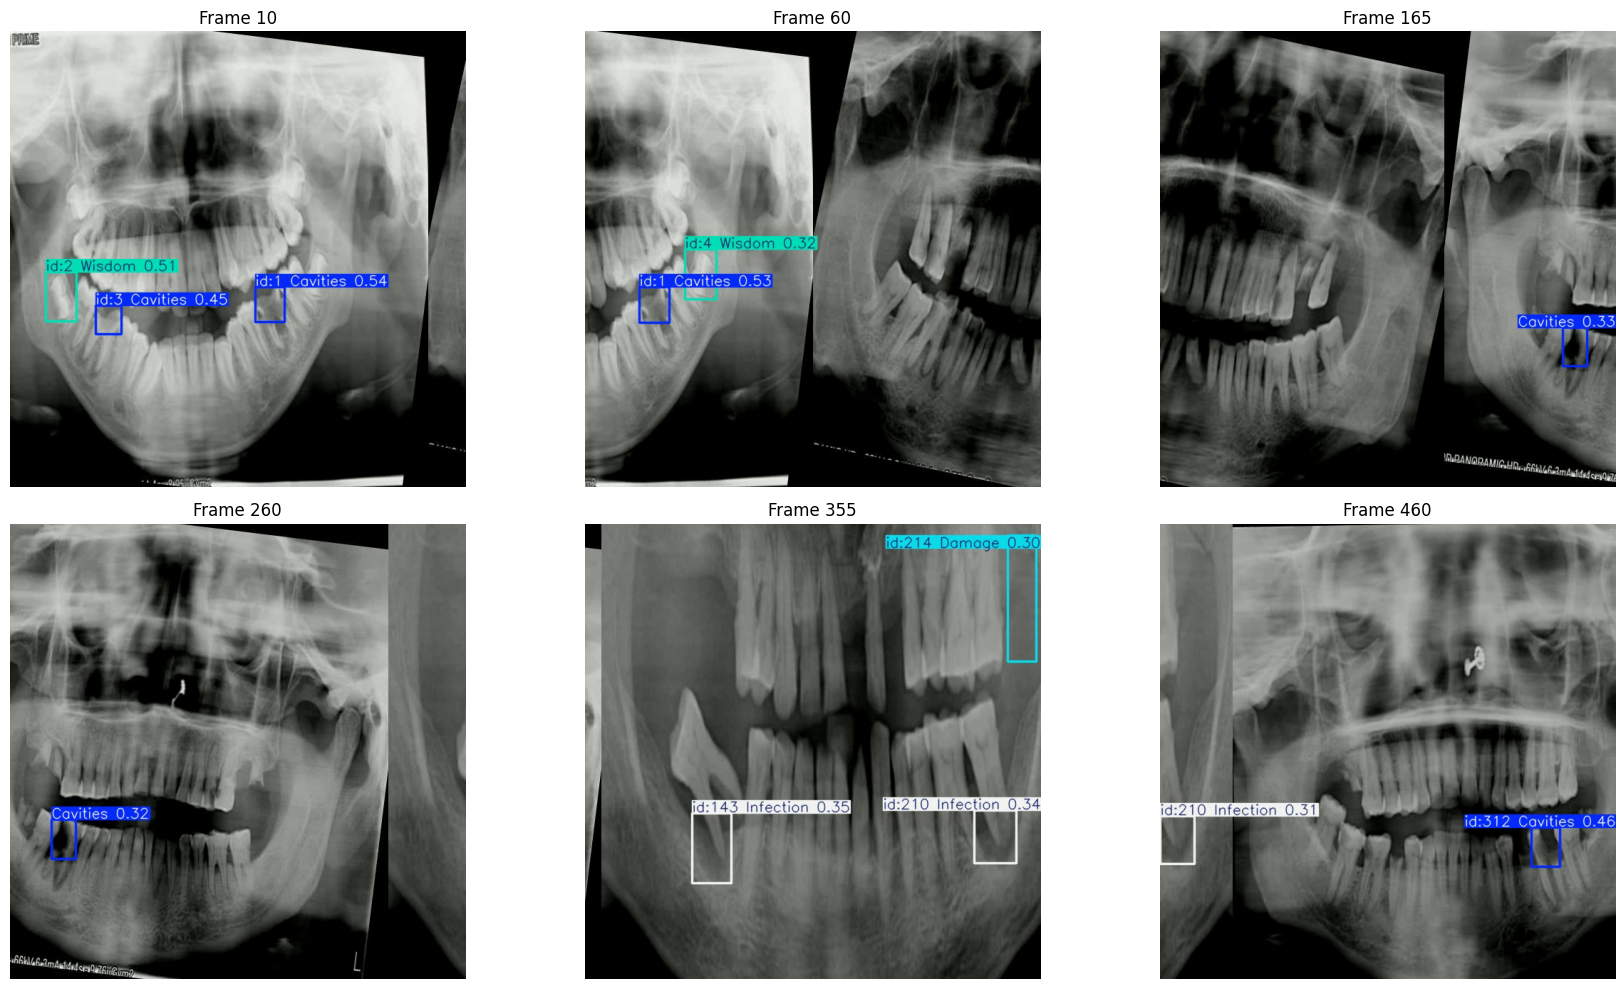

In [14]:
import cv2
import matplotlib.pyplot as plt

sample_indices = [10, 60, 165, 260, 355, 460]  # spread across different scenes/classes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cap = cv2.VideoCapture('/kaggle/working/runs/tracking_output/synthetic_tracking_video.avi')
for i, frame_idx in enumerate(sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {frame_idx}")
    axes[i].axis('off')
cap.release()

plt.tight_layout()
plt.savefig('/kaggle/working/tracking_representative_frames.png', dpi=150, bbox_inches='tight')
plt.show()

Cell — document the tracker configuration (required by spec: "state your association parameters")

In [15]:
import yaml
from ultralytics.utils import checks

bytetrack_path = checks.check_yaml('bytetrack.yaml')
with open(bytetrack_path, 'r') as f:
    tracker_config = yaml.safe_load(f)
print(tracker_config)

{'tracker_type': 'bytetrack', 'track_high_thresh': 0.25, 'track_low_thresh': 0.1, 'new_track_thresh': 0.25, 'track_buffer': 30, 'match_thresh': 0.8, 'fuse_score': True}


## Tracking Pipeline Configuration

- **Detector:** DINOv3-initialized YOLOv12-m (Task 1 winner, test mAP50-95=0.2054 at ρ=0.20)
- **Tracker:** ByteTrack (via Ultralytics `.track()` interface), using default association 
  parameters (see printed config above) — chosen over BoT-SORT for its native support for 
  low-confidence detection recovery, relevant given our detector's modest confidence scores 
  (0.22-0.81 range observed across Task 1 qualitative panels).
- **Video source:** synthetic panning video (Section on Video Source, above), 480 frames, 
  24fps, 20 seconds, with exact frame-level ground truth derived from real annotations.
- **Confidence threshold:** 0.25

## Tracking Pipeline Configuration

- **Detector:** DINOv3-initialized YOLOv12-m (Task 1 winner, test mAP50-95=0.2054 at ρ=0.20)
- **Tracker:** ByteTrack, via Ultralytics' `.track()` interface, with the following association 
  parameters:
  - `track_high_thresh=0.25` — minimum confidence for a detection to seed/extend a high-confidence track
  - `track_low_thresh=0.1` — minimum confidence for a detection to be considered in the second-stage, 
    low-confidence association pass (ByteTrack's core innovation — recovering weak detections that 
    would otherwise be discarded)
  - `new_track_thresh=0.25` — minimum confidence to spawn a brand-new track ID
  - `track_buffer=30` — number of frames a lost track is kept alive before being deleted, allowing 
    re-identification after brief detection gaps
  - `match_thresh=0.8` — IoU threshold for associating a detection with an existing track
  - `fuse_score=True` — combines detection confidence with IoU when computing association cost
- **Video source:** synthetic panning video (480 frames, 24fps, 20s), built from 5 real, 
  fully-annotated test-set X-rays, with exact frame-level ground truth computed from the known 
  camera-window geometry.
- **Confidence threshold for detection:** 0.25

In [16]:
present_files_list = [
    '/kaggle/working/annotated_tracking_output.mp4',
    '/kaggle/working/tracking_representative_frames.png',
    '/kaggle/working/video_sample_frames.png',
]
for f in present_files_list:
    print(f, os.path.exists(f))

/kaggle/working/annotated_tracking_output.mp4 True
/kaggle/working/tracking_representative_frames.png True
/kaggle/working/video_sample_frames.png True
